# Summary Statistics

## Overview

This notebook computes descriptive statistics for the harmonized SAMBBA dataset and generates summary figures describing the physicochemical composition and optical properties of biomass-burning aerosol. These diagnostics provide an overview of the processed observations before the statistical modelling stage.

## Workflow

1. Load the harmonized datasets generated during preprocessing.
2. Combine observations from the selected research flights.
3. Compute descriptive statistics for the variables of interest.
4. Generate publication-quality summary figures.

## Inputs

- Harmonized datasets generated during the preprocessing workflow.

## Outputs

- Summary statistics tables.
- Publication-quality summary figures.

## Requirements

This notebook assumes that the preprocessing workflow has already been completed and that the processed datasets are available within the repository directory structure.


In [16]:
# Import the libraries required for data processing, statistical analysis and visualization.
import re
import numpy as np
import xarray as xr
import pandas as pd
from flights_io_commented  import get_matched_flights
from flight_processing_commented import process_flight
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt

In [17]:
# Define the location of the SAMBBA flight archive and identify the flights to be included in the analysis.
base_dir = "/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012"

dirs =  [
    "b732-sep-15", "b733-sep-16", 
    "b734-sep-18", "b735-sep-19", "b736-sep-19", "b737-sep-20", "b738-sep-22", 
    "b739-sep-23", "b742-sep-27", "b743-sep-27", 
    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b748-oct-02", 
    "b749-oct-03", 
]

flights = get_matched_flights(base_dir, dirs)

for flight in flights:
    print(flight.core_cloud)

Matched flights: 10
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b734-sep-18/core_processed/core-cloud-phy_faam_20120918_v500_r0_b734.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b737-sep-20/core_processed/core-cloud-phy_faam_20120920_v500_r0_b737.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b739-sep-23/core_processed/core-cloud-phy_faam_20120923_v500_r0_b739.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b742-sep-27/core_processed/core-cloud-phy_faam_20120927_v500_r0_b742.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b743-sep-27/core_processed/core-cloud-phy_faam_20120927_v500_r0_b743.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b744-sep-28/core_processed/core-cloud-phy_faam_20120928_v500_r0_b744.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b745-sep-28/core_processed/core-cloud-phy_faam_20120928_v500_r0_b745.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2

In [18]:
# Process each research flight individually, synchronize measurements from the different instruments and store the variables required for the combined analysis.
results = []

for flight in flights:
    out = process_flight(flight)

    # Retain only the timestamps shared by the FAAM core, AMS and SP2
    # datasets. Restricting the analysis to concurrent measurements
    # ensures that all variables describe the same atmospheric conditions.
    common_times = np.intersect1d(out.core.data_point.values, out.ams.time.values)
    # Then intersect with SP2
    common_times = np.intersect1d(common_times, out.sp2.time.values)
    
    
    core_file_matched = out.core.sel(data_point=common_times)
    ams_resampled_matched = out.ams.sel(time=common_times)
    sp2_resampled_matched = out.sp2.sel(time=common_times)
    resampled_neph_matched = out.neph.sel(time=common_times)
    Dg_aligned_matched = out.Dgs.reindex(pd.to_datetime(common_times), method="nearest")
    PM_ratio_matched = out.PM_ratio.sel(PCAS2TSPM = common_times)
    
    # Core file variables
    Height = core_file_matched['GPS_ALT'].values.squeeze()
    Lon = core_file_matched['LON_GPS'].values.squeeze()
    Lat = core_file_matched['LAT_GPS'].values.squeeze()
    CO_conc_matched = core_file_matched['CO_AERO'].values.squeeze()
    PSAP_matched = core_file_matched['PSAP_LIN'].values.squeeze()

    # Cabin conditions
    CAB_PRES = core_file_matched["CAB_PRES"].values.squeeze()      # hPa
    CAB_TEMP = core_file_matched["CAB_TEMP"].values.squeeze() + 273.15  # K

    #Neph file variables
    TSC_blue = resampled_neph_matched["TSC_BLUU"].values.squeeze()
    TSC_green = resampled_neph_matched["TSC_GRNU"].values.squeeze()
    TSC_red = resampled_neph_matched["TSC_REDU"].values.squeeze()

    # STP reference
    P_STP = 1013.25   # hPa
    T_STP = 273.15    # K

    conversion_factor = (CAB_PRES / P_STP) * (T_STP / CAB_TEMP)

    #Sp2 file variables
    BC = sp2_resampled_matched.values * conversion_factor  # Convert to ATP conditions
    #AMS file variables
    ORG = ams_resampled_matched['ORG'].values * conversion_factor  # Convert to ATP conditions
    ORG_unc = ams_resampled_matched['ORG_uncertainty'].values * conversion_factor  # Convert to ATP conditions
    SO4 = ams_resampled_matched['SO4'].values * conversion_factor  # Convert to ATP conditions
    SO4_unc = ams_resampled_matched['SO4_uncertainty'].values * conversion_factor  # Convert to ATP conditions
    NH4 = ams_resampled_matched['NH4'].values * conversion_factor  # Convert to ATP conditions
    NH4_unc = ams_resampled_matched['NH4_uncertainty'].values * conversion_factor  # Convert to ATP conditions
    NO3 = ams_resampled_matched['NO3'].values * conversion_factor  # Convert to ATP conditions
    NO3_unc = ams_resampled_matched['NO3_uncertainty'].values * conversion_factor  # Convert to ATP conditions
    AS = ams_resampled_matched['NH4_2SO4'].values * conversion_factor  # Convert to ATP conditions
    AN = ams_resampled_matched['NH4NO3'].values * conversion_factor  # Convert to ATP conditions
    #PCASP variables
    Dg = Dg_aligned_matched
    ratio_pm = PM_ratio_matched
    
    
    # Extract the flight number (b###) from the file path
    match = re.search(r'b\d{3}', flight.core)  # Looks for 'b' followed by 3 digits
    flight_number = match.group(0) if match else "Unknown"
    
    results.append({
        'ORG': ORG,
        'BC': BC,
        'SO4': SO4,
        'NH4': NH4,
        'NO3': NO3,
        'AS': AS,
        'AN': AN,
        'TSC_blue':TSC_blue,
        'TSC_green':TSC_green,
        'TSC_red':TSC_red,
        'ABS_PSAP':PSAP_matched,
        'DG_aligned': Dg,
        'PM_ratio': ratio_pm,
        'CO': CO_conc_matched,
        'ALT' : Height,
        'LON': Lon,
        'LAT': Lat,
        'flight': flight_number
    })

In [19]:
# Merge the processed observations from all flights into a single DataFrame for the statistical analyses.
# Combine all flight data
combined_data = []
for entry in results:
    try:
        df = pd.DataFrame({
            'TSC_blue': entry['TSC_blue'],
            'TSC_green': entry['TSC_green'],
            'TSC_red': entry['TSC_red'],
            'ABS_PSAP':entry['ABS_PSAP'],
            'rBC': entry['BC'],
            'SO4': entry['SO4'],
            'NH4': entry['NH4'],
            'NO3': entry['NO3'],
            'AS': entry['AS'],
            'AN': entry['AN'],
            'OA': entry['ORG'],
            'DG': entry['DG_aligned'],
            'PM_coarse': entry['PM_ratio'],
            'ALT' : entry['ALT'],
            'LON': entry['LON'],
            'LAT': entry['LAT'],
            'CO': entry['CO'],
            'Flight': entry['flight']
        })

        combined_data.append(df)
    except Exception as e:
        print(f"Skipping flight {entry['flight']} due to error: {e}")

# Concatenate all flights
df_all = pd.concat(combined_data)
df_clean = df_all.replace([np.inf, -np.inf], np.nan).dropna()

In [20]:
# Define the variable groups
scattering_vars = ['TSC_green']
absorption_vars = ['ABS_PSAP']
chemistry_vars = ['rBC', 'SO4', 'NH4', 'NO3', 'OA']
other_vars = ['CO']

In [21]:
def summarize_optical(
    df,
    scattering_vars,
    absorption_vars,
    other_vars,
    chemistry_vars
):
    """
    Compute summary statistics with:
    - scaling for optical variables (Mm^-1)
    - unit-aware output
    - total mass from chemistry
    """

    summary = []

    # Create a local copy to preserve the original DataFrame and compute
    # the total aerosol mass concentration from the measured chemical species.
    df = df.copy()
    df["Total_mass"] = df[chemistry_vars].sum(axis=1)

    # Define the variables to be summarized and classify them according
    # to their physical meaning. The variable type is later used to apply
    # the appropriate unit conversion and metadata.
    all_vars = (
        [(v, "scattering") for v in scattering_vars] +
        [(v, "absorption") for v in absorption_vars] +
        [(v, "other") for v in other_vars] +
        [("Total_mass", "mass")]
    )

    # Compute descriptive statistics for each variable independently.
    for var, vtype in all_vars:
        data = df[var].dropna()

        # Convert optical coefficients from m⁻¹ to Mm⁻¹ to match the
        # convention adopted. Assign the
        # corresponding units to each variable.
        if vtype in ["scattering", "absorption"]:
            data = data * 1e6
            unit = "Mm⁻¹"
        elif var == "CO":
            unit = "ppb"
        elif var == "Total_mass":
            unit = "µg m⁻³"
        else:
            unit = "-"

        # Store the summary statistics used to characterize the complete
        # observational dataset.
        summary.append({
            "variable": var,
            "type": vtype,
            "mean": data.mean(),
            "std": data.std(),
            "p5": np.percentile(data, 5),
            "p95": np.percentile(data, 95),
            "N": data.count(),
            "unit": unit
        })

    return pd.DataFrame(summary)

In [22]:
def summarize_chemistry_fraction(df, chemistry_vars):
    """
    Compute the relative (%) contribution of each chemical species to the
    total measured aerosol mass.

    Returns descriptive statistics of the species mass fractions across
    all observations.
    """

    # Compute the total measured aerosol mass for each observation using
    # the chemical species included in the analysis.
    total_mass = df[chemistry_vars].sum(axis=1)

    # Replace zero-mass observations with NaN to avoid undefined
    # fractional contributions during the normalization step.
    total_mass = total_mass.replace(0, np.nan)

    # Express each species as its percentage contribution to the total
    # measured aerosol mass.
    fractions = df[chemistry_vars].div(total_mass, axis=0) * 100

    summary = []

    # Compute descriptive statistics for the mass fraction of each
    # chemical species across the complete dataset.
    for var in chemistry_vars:
        data = fractions[var].dropna()

        summary.append({
            "variable": var,
            "mean_pct": data.mean(),
            "std_pct": data.std(),
            "p5": np.percentile(data, 5),
            "p95": np.percentile(data, 95),
            "N": data.count()
        })

    return pd.DataFrame(summary)

In [23]:
def build_summary(
    df,
    scattering_vars,
    absorption_vars,
    other_vars,
    chemistry_vars
):
    """
    Generate the summary tables used to characterize the observational dataset.

    Two independent summaries are produced:
    - optical properties (including aerosol mass and auxiliary variables);
    - relative chemical composition expressed as species mass fractions.

    Returns
    -------
    pandas.DataFrame
        Summary statistics for the optical and auxiliary variables.

    pandas.DataFrame
        Summary statistics for the chemical composition.
    """

    # Compute descriptive statistics for the optical properties,
    # aerosol mass, and ancillary variables.
    optical_summary = summarize_optical(
        df,
        scattering_vars,
        absorption_vars,
        other_vars,
        chemistry_vars
    )

    optical_summary["category"] = "optical"

    # Compute the relative contribution of each chemical species to the
    # total measured aerosol mass.
    chem_summary = summarize_chemistry_fraction(df, chemistry_vars)
    chem_summary["category"] = "chemistry"

    return optical_summary, chem_summary

In [24]:
# Generate the summary tables describing the optical properties and
# chemical composition of the quality-controlled observational dataset.
optical_all, chem_all = build_summary(
    df_clean,
    scattering_vars,
    absorption_vars,
    other_vars,
    chemistry_vars
)

In [25]:
# Compute summary statistics independently for each research flight.
# This allows the variability between flights to be assessed in addition
# to the statistics derived from the complete observational dataset.
flight_summaries = {}

for flight_id, df_flight in df_clean.groupby("Flight"):

    optical, chem = build_summary(
        df_flight,
        scattering_vars,
        absorption_vars,
        other_vars,
        chemistry_vars
    )

    # Store the optical and chemical summaries using the flight
    # identifier as the dictionary key.
    flight_summaries[flight_id] = {
        "optical": optical,
        "chemistry": chem
    }

In [26]:
def plot_summary_si_v4(
    optical_df,
    chem_df,
    title="Summary Statistics"
):
    """
    Generate a publication-quality summary figure combining descriptive
    statistics and the average aerosol chemical composition.

    The figure consists of:
    - a table summarizing the optical and ancillary variables;
    - a pie chart showing the mean relative contribution of each aerosol
      chemical species to the total measured aerosol mass.

    Parameters
    ----------
    optical_df : pandas.DataFrame
        Summary statistics for the optical and ancillary variables.

    chem_df : pandas.DataFrame
        Summary statistics of the aerosol chemical composition.

    title : str, optional
        Title displayed above the summary table.

    Returns
    -------
    matplotlib.figure.Figure
        Figure object.

    tuple
        Tuple containing the table and pie chart axes.
    """

    import matplotlib.pyplot as plt

    # Define a consistent color scheme for the aerosol species. These
    # colors are used throughout the manuscript to facilitate comparison
    # between different figures.
    color_map = {
        "rBC": "black",
        "SO4": "red",
        "NH4": "orange",
        "OA": "green",
        "NO3": "navy",
    }

    # Display chemical formulas using publication-style notation.
    label_map = {
        "rBC": "rBC",
        "SO4": "SO₄²⁻",
        "NH4": "NH₄⁺",
        "OA": "OA",
        "NO3": "NO₃⁻",
    }

    # Configure figure aesthetics following the style adopted throughout
    # the manuscript.
    plt.rcParams.update({
        "font.size": 9,
        "axes.titlesize": 11,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
    })

    # ------------------------------------------------------------------
    # Create the figure layout with the summary table positioned above
    # the pie chart.
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(5, 7))

    gs = fig.add_gridspec(
        2,
        1,
        height_ratios=[1.15, 1],
        hspace=0.02
    )

    ax_table = fig.add_subplot(gs[0])
    ax_pie = fig.add_subplot(gs[1])

    # ==================================================================
    # Summary table
    # ==================================================================
    ax_table.axis("off")

    col_labels = [
        "Variable",
        "Mean ± SD",
        "p5",
        "p95",
        "Unit"
    ]

    table_data = []

    # Populate the summary table with the descriptive statistics
    # computed for the complete observational dataset.
    for _, row in optical_df.iterrows():
        table_data.append([
            row["variable"],
            f"{row['mean']:.2f} ± {row['std']:.0f}",
            f"{row['p5']:.2f}",
            f"{row['p95']:.2f}",
            row["unit"]
        ])

    table = ax_table.table(
        cellText=table_data,
        colLabels=col_labels,
        loc="center",
        cellLoc="center",
        colLoc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.25, 1.8)

    # Emphasize the column headers for improved readability.
    for (r, c), cell in table.get_celld().items():

        if r == 0:
            cell.set_text_props(weight="bold")
            cell.set_height(cell.get_height() * 1.15)

    # Add a title row above the table, including the number of
    # observations used to compute the summary statistics.
    n_cols = len(col_labels)

    header_height = table[(0, 0)].get_height()

    for col in range(n_cols):

        text = ""

        if col == n_cols // 2:
            text = f"{title} (N = {optical_df['N'].iloc[0]})"

        table.add_cell(
            -1,
            col,
            width=table[(0, col)].get_width(),
            height=header_height * 1.35,
            text=text,
            loc="center",
            facecolor="#F2F2F2"
        )

    # Hide the internal borders of the title row to create the
    # appearance of a single merged header.
    for col in range(n_cols):

        cell = table[(-1, col)]

        cell.set_text_props(
            fontsize=11,
            fontweight="bold"
        )

        if col == 0:
            cell.visible_edges = "LTB"
        elif col == n_cols - 1:
            cell.visible_edges = "RTB"
        else:
            cell.visible_edges = "TB"

    # ==================================================================
    # Pie chart
    # ==================================================================

    # Remove missing values and order the aerosol species according to
    # their mean contribution to the total measured aerosol mass.
    chem_df_clean = (
        chem_df
        .dropna(subset=["mean_pct"])
        .sort_values("mean_pct", ascending=False)
    )

    plot_labels = [
        label_map.get(v, v)
        for v in chem_df_clean["variable"]
    ]

    plot_colors = [
        color_map.get(v, "lightgray")
        for v in chem_df_clean["variable"]
    ]

    wedges, texts, autotexts = ax_pie.pie(
        chem_df_clean["mean_pct"],
        labels=plot_labels,
        colors=plot_colors,
        startangle=90,
        autopct="%1.1f%%",
        pctdistance=1.22,
        labeldistance=1.45,
        radius=1.15,
        wedgeprops=dict(
            edgecolor="white",
            linewidth=0.8
        ),
        textprops=dict(
            fontsize=9
        )
    )

    # Reduce the size of the percentage labels to improve readability.
    for txt in autotexts:
        txt.set_fontsize(8)

    # Place the panel title below the pie chart to maximize the available
    # space for the labels.
    ax_pie.text(
        0.5,
        -0.18,
        "Average aerosol chemical composition",
        transform=ax_pie.transAxes,
        ha="center",
        va="top",
        fontsize=11
    )

    return fig, (ax_table, ax_pie)

(<Figure size 500x700 with 2 Axes>, (<Axes: >, <Axes: >))

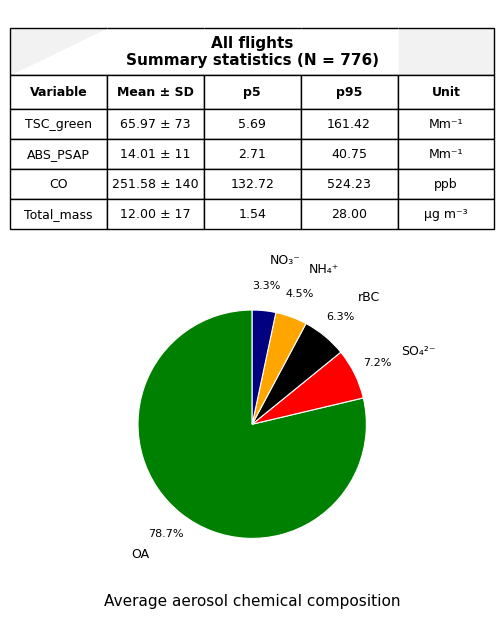

In [27]:
# Generate a summary figure for the complete observational dataset,
# combining the descriptive statistics and the average aerosol
# chemical composition across all selected flights.
plot_summary_si_v4(
    optical_all,
    chem_all,
    title="All flights\nSummary statistics"
)

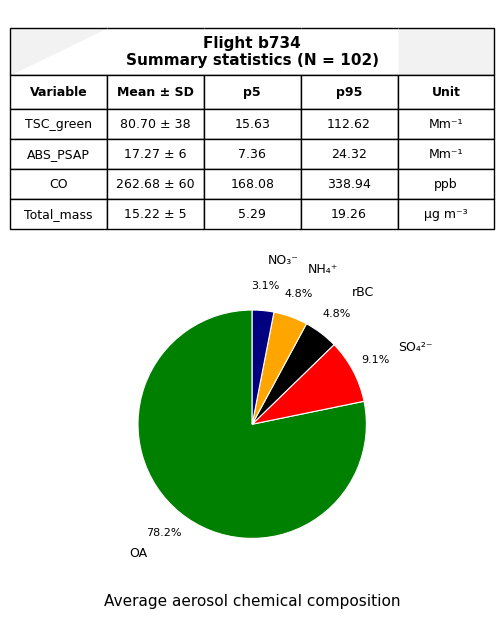

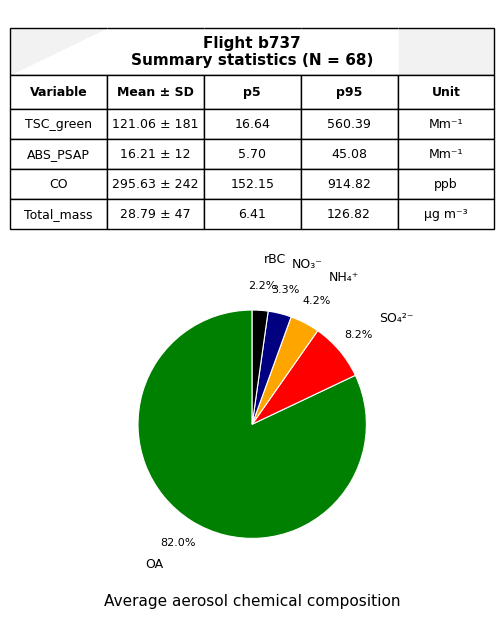

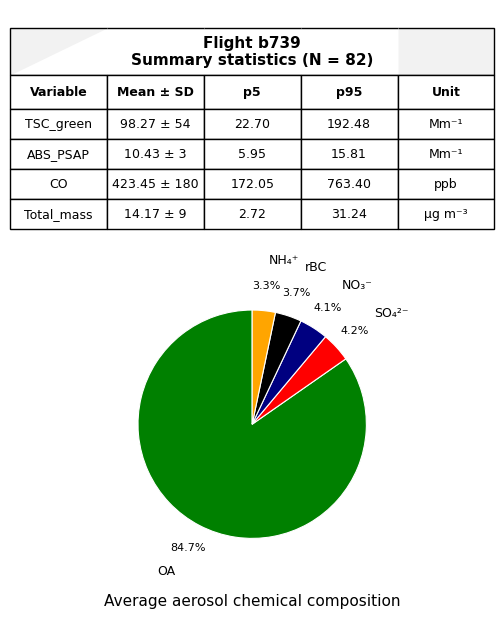

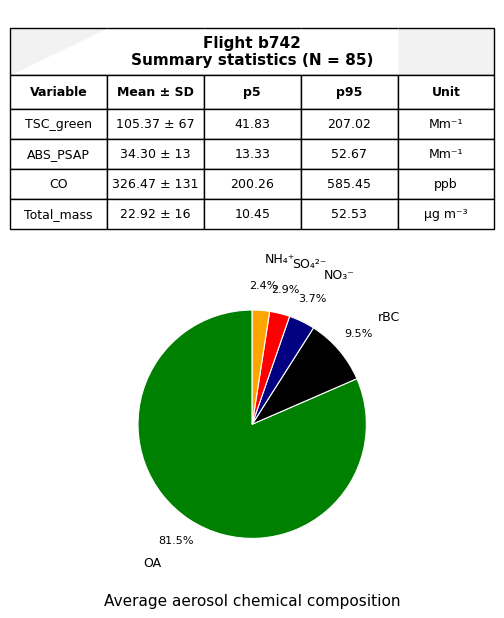

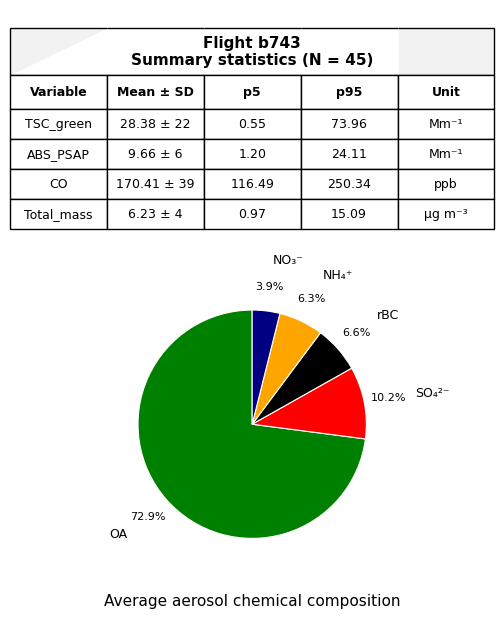

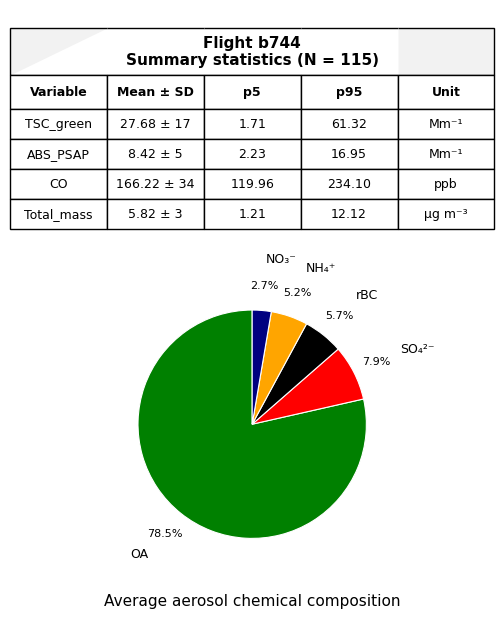

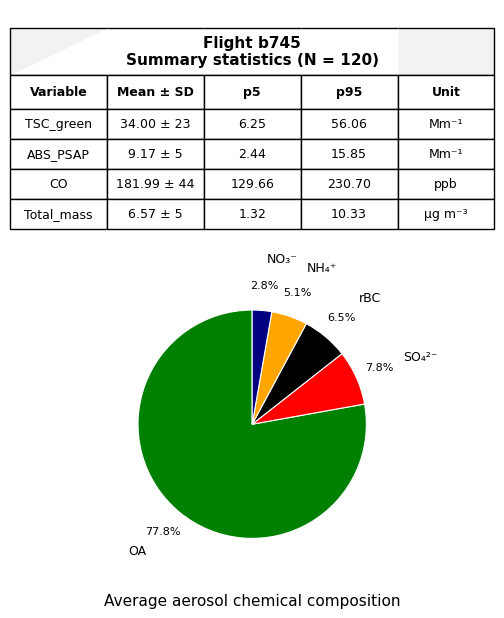

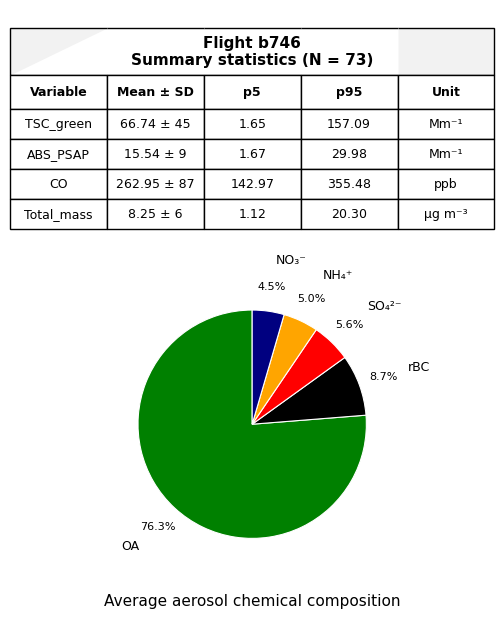

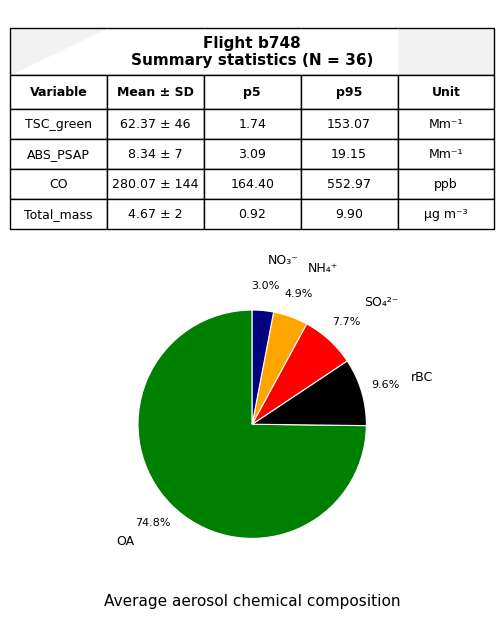

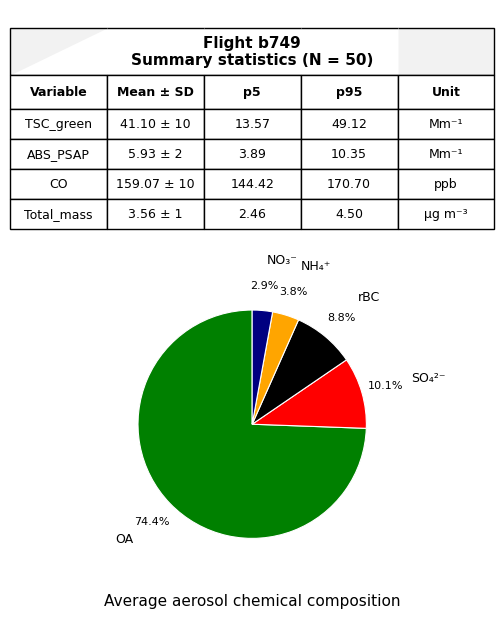

In [28]:
# Generate summary figures for each individual research flight. These
# figures provide a flight-by-flight overview of the optical properties
# and aerosol chemical composition, allowing variability between flights
# to be evaluated.
for flight_id, data in flight_summaries.items():

    plot_summary_si_v4(
        data["optical"],
        data["chemistry"],
        title=f"Flight {flight_id}\nSummary statistics"
    )